<a href="https://colab.research.google.com/github/andrebrandaopro/Lista2/blob/Portf%C3%B3lio/q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-tuning de CNN Pré-treinada na CIFAR-10

Neste notebook, além de avaliar uma ResNet18 pré-treinada para CIFAR-10, realizaremos o fine-tuning do modelo, ajustando seus pesos com parte do conjunto de treino. Compararemos o desempenho antes e depois do ajuste fino.

## O que é Fine-Tuning?

Fine-tuning consiste em ajustar uma rede neural já treinada em um grande dataset para uma tarefa ou conjunto de dados específico. Normalmente, as camadas iniciais são mantidas (apenas atualizando pesos das finais), acelerando o treinamento e melhorando a performance na tarefa alvo.

In [1]:
import timm
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Carregar e visualizar a base CIFAR-10

In [2]:
# Transforms (inclui data augmentation para treino)
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)
classes = ['avião', 'automóvel', 'pássaro', 'gato', 'cervo', 'cachorro', 'sapo', 'cavalo', 'navio', 'caminhão']

100%|██████████| 170M/170M [00:07<00:00, 23.5MB/s]


## Carregar a ResNet18 Pré-treinada e Preparar para Fine-Tuning

Por padrão, a ResNet18 do TIMM já está ajustada para CIFAR-10. Para fins didáticos, vamos simular o fine-tuning congelando as primeiras camadas e ajustando apenas as finais (último bloco).

In [4]:
# Load a standard ResNet18 pre-trained on ImageNet
model = timm.create_model('resnet18', pretrained=True)

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)

model = model.to(device)

for name, param in model.named_parameters():
    if not name.startswith('layer4') and not name.startswith('fc'):
        param.requires_grad = False

# Checar quantos parâmetros serão treinados
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f'Parâmetros treináveis: {n_trainable} / {n_total}')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Parâmetros treináveis: 8398858 / 11181642


## Treinamento (Fine-Tuning)

Vamos ajustar apenas as últimas camadas por algumas épocas (exemplo: 5), suficiente para demonstrar o efeito do fine-tuning.

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

n_epochs = 5
for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if (i+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{n_epochs}], Batch [{i+1}/{len(trainloader)}], Loss: {running_loss/100:.4f}')
            running_loss = 0.0
print('Fine-tuning concluído.')

Epoch [1/5], Batch [100/391], Loss: 1.9300
Epoch [1/5], Batch [200/391], Loss: 1.5714
Epoch [1/5], Batch [300/391], Loss: 1.4525
Epoch [2/5], Batch [100/391], Loss: 1.3224
Epoch [2/5], Batch [200/391], Loss: 1.3060
Epoch [2/5], Batch [300/391], Loss: 1.2668
Epoch [3/5], Batch [100/391], Loss: 1.2254
Epoch [3/5], Batch [200/391], Loss: 1.1790
Epoch [3/5], Batch [300/391], Loss: 1.1954
Epoch [4/5], Batch [100/391], Loss: 1.1526
Epoch [4/5], Batch [200/391], Loss: 1.1249
Epoch [4/5], Batch [300/391], Loss: 1.1379
Epoch [5/5], Batch [100/391], Loss: 1.0894
Epoch [5/5], Batch [200/391], Loss: 1.0875
Epoch [5/5], Batch [300/391], Loss: 1.0861
Fine-tuning concluído.


## Avaliação do Modelo após Fine-Tuning

Geramos a matriz de confusão, relatório de classificação e exemplos de erro/acerto para avaliar o impacto do fine-tuning.

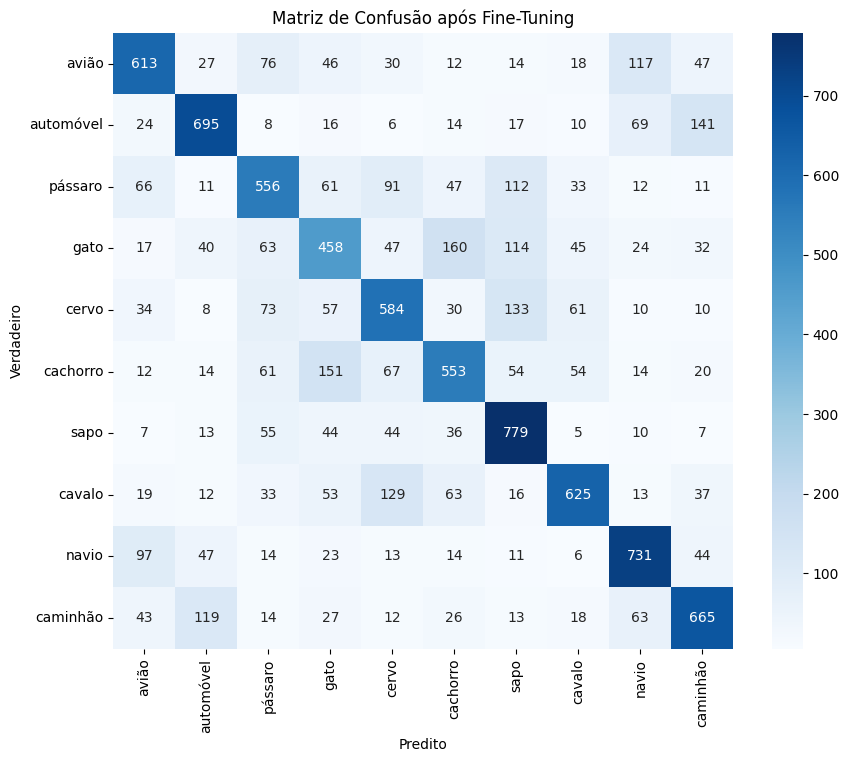

              precision    recall  f1-score   support

       avião      0.658     0.613     0.635      1000
   automóvel      0.705     0.695     0.700      1000
     pássaro      0.583     0.556     0.569      1000
        gato      0.489     0.458     0.473      1000
       cervo      0.571     0.584     0.577      1000
    cachorro      0.579     0.553     0.566      1000
        sapo      0.617     0.779     0.688      1000
      cavalo      0.714     0.625     0.667      1000
       navio      0.688     0.731     0.709      1000
    caminhão      0.656     0.665     0.660      1000

    accuracy                          0.626     10000
   macro avg      0.626     0.626     0.624     10000
weighted avg      0.626     0.626     0.624     10000


Acurácia total no teste: 62.59%


In [6]:
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão após Fine-Tuning')
plt.show()

print(classification_report(y_true, y_pred, target_names=classes, digits=3))
acc = np.mean(np.array(y_true) == np.array(y_pred))
print(f'\nAcurácia total no teste: {acc*100:.2f}%')

## Exemplos de Erros e Acertos após Fine-Tuning

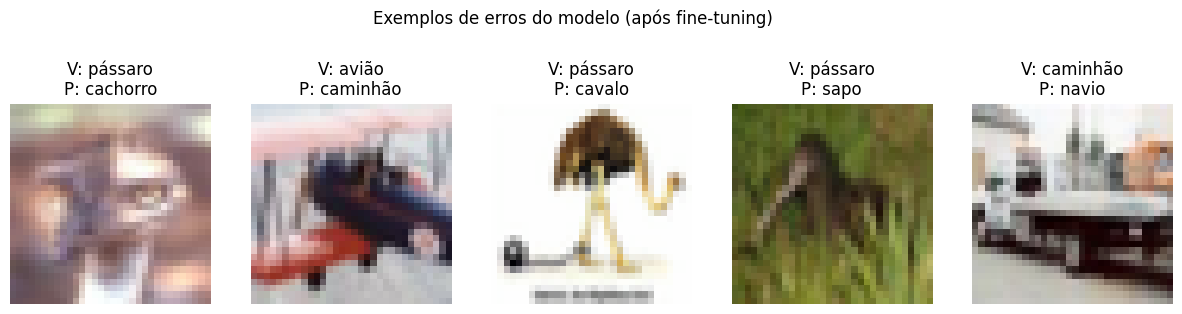

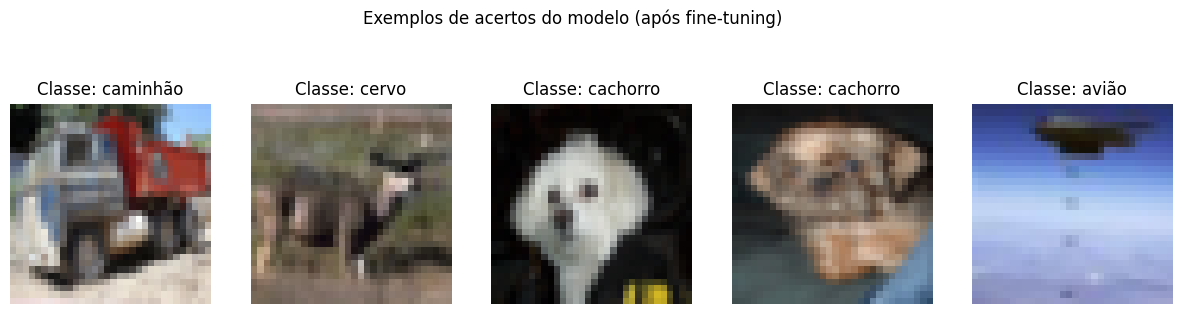

In [7]:
import random
# Erros
wrong_idxs = [i for i, (a, p) in enumerate(zip(y_true, y_pred)) if a != p]
plt.figure(figsize=(15,4))
for i, idx in enumerate(random.sample(wrong_idxs, 5)):
    img, label = testset[idx]
    plt.subplot(1, 5, i+1)
    img_np = img.numpy()
    img_np = img_np * np.array([0.2023, 0.1994, 0.2010]).reshape(3,1,1) + np.array([0.4914, 0.4822, 0.4465]).reshape(3,1,1)
    img_np = np.clip(img_np, 0, 1)
    plt.imshow(np.transpose(img_np, (1,2,0)))
    plt.title(f"V: {classes[label]}\nP: {classes[y_pred[idx]]}")
    plt.axis('off')
plt.suptitle('Exemplos de erros do modelo (após fine-tuning)')
plt.show()

# Acertos
right_idxs = [i for i, (a, p) in enumerate(zip(y_true, y_pred)) if a == p]
plt.figure(figsize=(15,4))
for i, idx in enumerate(random.sample(right_idxs, 5)):
    img, label = testset[idx]
    plt.subplot(1, 5, i+1)
    img_np = img.numpy()
    img_np = img_np * np.array([0.2023, 0.1994, 0.2010]).reshape(3,1,1) + np.array([0.4914, 0.4822, 0.4465]).reshape(3,1,1)
    img_np = np.clip(img_np, 0, 1)
    plt.imshow(np.transpose(img_np, (1,2,0)))
    plt.title(f"Classe: {classes[label]}")
    plt.axis('off')
plt.suptitle('Exemplos de acertos do modelo (após fine-tuning)')
plt.show()

## Conclusão

- O fine-tuning permite personalizar e melhorar a performance do modelo para o conjunto de dados alvo.
- Mesmo redes já pré-treinadas podem se beneficiar do ajuste fino, especialmente em classes mais difíceis.
- Visualizar os erros e acertos ajuda a identificar limitações e potenciais melhorias futuras (data augmentation, ensembles, etc).